# SAJU ML All-Feature Automatic Selection Tournament V3

**Notebook version:** `SAJU_ML_ALL_FEATURE_TOURNAMENT_V3_20260815`

## Question

> If the model is allowed to choose freely from the currently available saju feature universe,
> is `TENGOD_ONLY` still the best architecture, or is there a better single/multi-feature combination?

This is a **discovery / architecture-selection** notebook.

## Discovery pool

We explicitly reclassify already-observed development data as discovery data:

- V1 Career pair-evaluable subjects: expected 23
- V2 `NEW_DEV`: expected 70
- combined discovery subjects: expected 93

`NEW_CONFIRM` is **never loaded**.

After this tournament, the provisional architecture must be frozen and tested on a completely new
`NEW_DEV_2` corpus before any sealed confirmation set is opened.

## Models compared

1. `TENGOD_FIXED`
   - current champion
   - exactly the frozen 10 Ten-God features
   - Pairwise Logistic, L2, C=0.3

2. `ALL_L2`
   - all available feature columns
   - Pairwise Logistic, L2, C=0.3
   - useful reference for whether simple shrinkage is enough

3. `ELASTICNET_AUTO`
   - all available features
   - inner subject-CV chooses C and L1 ratio
   - individual features are automatically zeroed / retained

4. `STABILITY_SELECTED`
   - starts from all available features
   - repeated subject bootstrap ElasticNet
   - only repeatedly selected features survive
   - final frozen linear ranker uses selected features

5. `HGB_CONTEXTUAL`
   - nonlinear challenger
   - static natal context + dynamic year-to-year feature differences
   - can learn contextual interactions without manually specifying them

## Why no deep neural network here?

With roughly 93 pair-evaluable subjects, a neural network has much more capacity than the evidence can support.
A nonlinear tree booster is a more defensible interaction challenger at this sample size.

## Hard boundaries

- Career only
- subject-level outer CV
- feature selection happens **inside outer training folds only**
- outer test subjects never participate in ElasticNet tuning or Stability Selection
- no `NEW_CONFIRM`
- no Public CHECK / FINAL
- no Validation B
- Production Control is benchmark-only, never an ML input

In [1]:
from pathlib import Path
from itertools import product
from collections import Counter, defaultdict
from datetime import datetime
import hashlib
import json
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from sklearn.ensemble import HistGradientBoostingClassifier
    HGB_AVAILABLE = True
except Exception:
    from sklearn.ensemble import GradientBoostingClassifier
    HGB_AVAILABLE = False

warnings.filterwarnings("ignore")

NOTEBOOK_VERSION = "SAJU_ML_ALL_FEATURE_TOURNAMENT_V3_20260815"

SEED = 20260815
TARGET_DOMAIN = "Career"

# Nested discovery evaluation
OUTER_REPEATS = 3
OUTER_FOLDS = 5
INNER_FOLDS = 4

# ElasticNet automatic-selection grid
ELASTIC_C_GRID = [0.03, 0.10, 0.30, 1.00]
ELASTIC_L1_GRID = [0.25, 0.50, 0.75, 1.00]

# Stability selection
STABILITY_RESAMPLES_OUTER = 25
STABILITY_RESAMPLES_FINAL = 100
STABILITY_THRESHOLD = 0.60
STABILITY_MAX_FEATURES = 40
STABILITY_MIN_FEATURES = 3

# Bootstrap comparison after repeated outer CV
N_BOOTSTRAP = 20000

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p] + list(p.parents):
        if (candidate / "saju_engine.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repo root containing saju_engine.py. "
        "Run this notebook inside the Chartpalja saju repo."
    )

REPO_ROOT = find_repo_root()

V1_CORPUS_PATH = REPO_ROOT / "research/ml_corpus/v1/SAJU_ML_CORPUS_V1.json"
V1_BASE_DIR = REPO_ROOT / "research/ml/artifacts/v1"
V13_EXTENDED_PATH = (
    REPO_ROOT / "research/ml/artifacts/v1_3/extended_astrology_features_v1_3.csv"
)

V2_DEV_PATH = REPO_ROOT / "research/ml_corpus/v2/SAJU_ML_CORPUS_V2_NEW_DEV.json"
V2_ENGINE_INPUTS_PATH = REPO_ROOT / "research/ml_corpus/v2/SAJU_ML_ENGINE_INPUTS_V2.json"
V2_CANDIDATE_FREEZE_PATH = (
    REPO_ROOT / "research/ml_corpus/v2/SAJU_ML_V2_CANDIDATE_FREEZE.json"
)
V2_DEV_FREEZE_PATH = REPO_ROOT / "research/ml/artifacts/v2/V2_DEV_WINNER_FREEZE.json"

ARTIFACT_DIR = REPO_ROOT / "research/ml/artifacts/v3_all_feature_tournament"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

V2_ALL_FEATURE_CACHE = (
    ARTIFACT_DIR / "V2_NEW_DEV_all_feature_table_v3.csv"
)

print("=" * 80)
print("NOTEBOOK VERSION:", NOTEBOOK_VERSION)
print("repo:", REPO_ROOT)
print("output:", ARTIFACT_DIR)
print("HGB implementation:",
      "HistGradientBoostingClassifier" if HGB_AVAILABLE
      else "GradientBoostingClassifier fallback")
print("=" * 80)

NOTEBOOK VERSION: SAJU_ML_ALL_FEATURE_TOURNAMENT_V3_20260815
repo: /Users/sangjinlee/Desktop/projects/saju
output: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v3_all_feature_tournament
HGB implementation: HistGradientBoostingClassifier


## 1. File and holdout preflight

The notebook intentionally does **not** define a path to `NEW_CONFIRM`.

In [2]:
required = {
    "V1 corpus": V1_CORPUS_PATH,
    "V1.3 extended features": V13_EXTENDED_PATH,
    "V2 NEW_DEV corpus": V2_DEV_PATH,
    "V2 engine inputs": V2_ENGINE_INPUTS_PATH,
    "V2 candidate freeze": V2_CANDIDATE_FREEZE_PATH,
    "V2 DEV freeze": V2_DEV_FREEZE_PATH,
}

missing = []
for label, path in required.items():
    ok = path.exists()
    print("%-30s %s  %s" % (label, "OK" if ok else "MISSING", path))
    if not ok:
        missing.append((label, str(path)))

v1_parquet = V1_BASE_DIR / "ml_feature_table_v1.parquet"
v1_csv = V1_BASE_DIR / "ml_feature_table_v1.csv"
if not v1_parquet.exists() and not v1_csv.exists():
    missing.append(
        ("V1 base feature cache", str(v1_parquet) + " OR " + str(v1_csv))
    )

if missing:
    raise FileNotFoundError("Missing required files: %s" % (missing,))

v2_dev_freeze = json.load(open(V2_DEV_FREEZE_PATH, encoding="utf-8"))
assert v2_dev_freeze["integrity"]["confirm_file_loaded"] is False

print("\nHOLDOUT GUARD: PASS")
print("Previous NEW_CONFIRM loaded:", v2_dev_freeze["integrity"]["confirm_file_loaded"])

V1 corpus                      OK  /Users/sangjinlee/Desktop/projects/saju/research/ml_corpus/v1/SAJU_ML_CORPUS_V1.json
V1.3 extended features         OK  /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v1_3/extended_astrology_features_v1_3.csv
V2 NEW_DEV corpus              OK  /Users/sangjinlee/Desktop/projects/saju/research/ml_corpus/v2/SAJU_ML_CORPUS_V2_NEW_DEV.json
V2 engine inputs               OK  /Users/sangjinlee/Desktop/projects/saju/research/ml_corpus/v2/SAJU_ML_ENGINE_INPUTS_V2.json
V2 candidate freeze            OK  /Users/sangjinlee/Desktop/projects/saju/research/ml_corpus/v2/SAJU_ML_V2_CANDIDATE_FREEZE.json
V2 DEV freeze                  OK  /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v2/V2_DEV_WINNER_FREEZE.json

HOLDOUT GUARD: PASS
Previous NEW_CONFIRM loaded: False


## 2. Build Career subject-year labels

Same rules as earlier notebooks:

- unknown is excluded
- conflicting positive/negative labels in the same subject-year are removed
- only subjects with at least one positive and one negative Career year are pair-evaluable

In [3]:
def build_target_rows(corpus, dataset_pool):
    raw = []

    for subject in corpus["subjects"]:
        birth = subject.get("birth") or {}
        if not birth.get("birth_time_known", True):
            continue

        for event in subject.get("events", []):
            if not event.get("ml_usable", True):
                continue

            label = (event.get("targets") or {}).get(TARGET_DOMAIN, "unknown")
            if label not in ("positive", "negative"):
                continue

            raw.append({
                "subject_id": subject["subject_id"],
                "name": subject["name"],
                "dataset_pool": dataset_pool,
                "origin_group": subject.get(
                    "origin_group",
                    subject.get("source_pool", dataset_pool),
                ),
                "year": int(event["year"]),
                "label": 1 if label == "positive" else 0,
                "confidence": event.get("source_event_confidence", "unknown"),
            })

    raw_df = pd.DataFrame(raw)
    collapsed = []
    collisions = []

    confidence_rank = {"high": 3, "medium": 2, "low": 1, "unknown": 0}

    for (sid, year), group in raw_df.groupby(["subject_id", "year"]):
        if group["label"].nunique() > 1:
            collisions.append({
                "subject_id": sid,
                "year": int(year),
            })
            continue

        best_conf = sorted(
            group["confidence"].astype(str),
            key=lambda x: confidence_rank.get(x, 0),
            reverse=True,
        )[0]

        collapsed.append({
            "subject_id": sid,
            "name": group["name"].iloc[0],
            "dataset_pool": dataset_pool,
            "origin_group": group["origin_group"].iloc[0],
            "year": int(year),
            "label": int(group["label"].iloc[0]),
            "confidence": best_conf,
        })

    out = pd.DataFrame(collapsed)

    pairable = []
    for sid, group in out.groupby("subject_id"):
        if set(group["label"].tolist()) == set([0, 1]):
            pairable.append(sid)

    out = out[out["subject_id"].isin(pairable)].copy()
    return out, pd.DataFrame(collisions)

v1_corpus = json.load(open(V1_CORPUS_PATH, encoding="utf-8"))
v2_dev_corpus = json.load(open(V2_DEV_PATH, encoding="utf-8"))

v1_targets, v1_collisions = build_target_rows(v1_corpus, "V1")
v2_targets, v2_collisions = build_target_rows(v2_dev_corpus, "V2_NEW_DEV")

print("V1 Career rows:", len(v1_targets))
print("V1 pairable subjects:", v1_targets["subject_id"].nunique())
print("V2 Career rows:", len(v2_targets))
print("V2 pairable subjects:", v2_targets["subject_id"].nunique())
print("collisions V1 / V2:", len(v1_collisions), len(v2_collisions))

assert v1_targets["subject_id"].nunique() == 23
assert v2_targets["subject_id"].nunique() == 70
assert set(v1_targets["subject_id"]).isdisjoint(set(v2_targets["subject_id"]))

V1 Career rows: 113
V1 pairable subjects: 23
V2 Career rows: 216
V2 pairable subjects: 70
collisions V1 / V2: 2 0


## 3. Load V1 full feature universe

V1 features come from two existing caches:

### V1 base

- raw natal / Daewoon / Sewoon stems and branches
- Five Elements / yin-yang
- natal element counts
- Ten-God groups
- hidden-stem counts
- 합/충/형/파/해 style relation counts
- engine strength bucket

### V1.3 extended

- Yongshin / Heeshin / Gishin / Gushin fit
- 12운성
- Shinsal / 귀인 / 공망 exported by the engine

In [4]:
if v1_parquet.exists():
    v1_base = pd.read_parquet(v1_parquet)
else:
    v1_base = pd.read_csv(v1_csv)

v1_extended = pd.read_csv(V13_EXTENDED_PATH)

feature_prefixes = (
    "basic__",
    "tengod__",
    "hidden__",
    "relation__",
    "engine__",
    "yongshin__",
    "unseong__",
    "shinsal__",
)

v1_base_keep = [
    "subject_id", "year"
] + [
    c for c in v1_base.columns
    if c.startswith(feature_prefixes) or c == "baseline__control_score"
]

v1_ext_keep = [
    "subject_id", "year"
] + [
    c for c in v1_extended.columns
    if c.startswith(("yongshin__", "unseong__", "shinsal__"))
]

v1_model_df = (
    v1_targets
    .merge(
        v1_base[v1_base_keep],
        on=["subject_id", "year"],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        v1_extended[v1_ext_keep],
        on=["subject_id", "year"],
        how="inner",
        validate="one_to_one",
    )
)

print("V1 model rows:", len(v1_model_df))
print("V1 model subjects:", v1_model_df["subject_id"].nunique())

v1_counts = {}
for prefix in feature_prefixes:
    v1_counts[prefix] = len(
        [c for c in v1_model_df.columns if c.startswith(prefix)]
    )
print("V1 feature counts:", v1_counts)

V1 model rows: 113
V1 model subjects: 23
V1 feature counts: {'basic__': 166, 'tengod__': 10, 'hidden__': 10, 'relation__': 21, 'engine__': 8, 'yongshin__': 16, 'unseong__': 28, 'shinsal__': 43}


## 4. V2 full-feature engine extraction

The prior V2 frozen-candidate cache only contained Ten-God and Shinsal.
For this tournament we rebuild **the full current feature universe** for the same 70 NEW_DEV subjects.

The formulas below preserve the semantics used in V1 / V1.3.

In [5]:
sys.path.insert(0, str(REPO_ROOT))

import saju_engine as se
import sajupy

STEMS = list("甲乙丙丁戊己庚辛壬癸")
BRANCHES = list("子丑寅卯辰巳午未申酉戌亥")
ELEMENTS = ["wood", "fire", "earth", "metal", "water"]

STEM_ELEMENT_EN = {
    "甲":"wood","乙":"wood","丙":"fire","丁":"fire","戊":"earth",
    "己":"earth","庚":"metal","辛":"metal","壬":"water","癸":"water"
}
STEM_YINYANG = {
    "甲":"yang","乙":"yin","丙":"yang","丁":"yin","戊":"yang",
    "己":"yin","庚":"yang","辛":"yin","壬":"yang","癸":"yin"
}
BRANCH_ELEMENT_EN = {
    "子":"water","丑":"earth","寅":"wood","卯":"wood","辰":"earth","巳":"fire",
    "午":"fire","未":"earth","申":"metal","酉":"metal","戌":"earth","亥":"water"
}
HIDDEN_STEMS = {
    "子":["癸"], "丑":["己","癸","辛"], "寅":["甲","丙","戊"], "卯":["乙"],
    "辰":["戊","乙","癸"], "巳":["丙","戊","庚"], "午":["丁","己"],
    "未":["己","丁","乙"], "申":["庚","壬","戊"], "酉":["辛"],
    "戌":["戊","辛","丁"], "亥":["壬","甲"]
}

GENERATES = {
    "wood":"fire","fire":"earth","earth":"metal","metal":"water","water":"wood"
}
CONTROLS = {
    "wood":"earth","earth":"water","water":"fire","fire":"metal","metal":"wood"
}

STEM_COMBINES = {
    frozenset(x)
    for x in [("甲","己"),("乙","庚"),("丙","辛"),("丁","壬"),("戊","癸")]
}
STEM_CLASHES = {
    frozenset(x)
    for x in [("甲","庚"),("乙","辛"),("丙","壬"),("丁","癸")]
}
BRANCH_COMBINES = {
    frozenset(x)
    for x in [("子","丑"),("寅","亥"),("卯","戌"),("辰","酉"),("巳","申"),("午","未")]
}
BRANCH_CLASHES = {
    frozenset(x)
    for x in [("子","午"),("丑","未"),("寅","申"),("卯","酉"),("辰","戌"),("巳","亥")]
}
BRANCH_HARMS = {
    frozenset(x)
    for x in [("子","未"),("丑","午"),("寅","巳"),("卯","辰"),("申","亥"),("酉","戌")]
}
BRANCH_BREAKS = {
    frozenset(x)
    for x in [("子","酉"),("丑","辰"),("寅","亥"),("卯","午"),("巳","申"),("未","戌")]
}
SELF_PUNISH = set(["辰","午","酉","亥"])
PUNISH_TRIPLES = [set("寅巳申"), set("丑未戌")]

UNSEONG_STATES = [
    "장생","목욕","관대","건록","제왕","쇠",
    "병","사","묘","절","태","양"
]
UNSEONG_START = {
    "甲":"亥", "乙":"午",
    "丙":"寅", "丁":"酉",
    "戊":"寅", "己":"酉",
    "庚":"巳", "辛":"子",
    "壬":"申", "癸":"卯",
}
YANG_STEMS = set("甲丙戊庚壬")
SHINSAL_KEYWORDS = ("신살", "귀인", "공망")

def parse_utc_offset(raw):
    if isinstance(raw, (int, float)):
        return float(raw)
    s = str(raw).strip()
    sign = -1.0 if s.startswith("-") else 1.0
    s = s[1:] if s[:1] in "+-" else s
    hh, mm = s.split(":")
    return sign * (int(hh) + int(mm) / 60.0)

def public_lon_corrected_birth(public_birth):
    y, m, d = map(int, public_birth["date"].split("-"))
    hh, mi = map(int, public_birth["time"].split(":")[:2])
    lon = float(public_birth["longitude"])
    utc_hours = parse_utc_offset(public_birth["utc_offset"])

    calc = sajupy.get_saju_calculator()
    civil = datetime(y, m, d, hh, mi)

    corr = float(
        calc._calculate_solar_time_correction(lon, utc_hours)
    )
    h2, min2, dc = calc._adjust_time_for_solar(
        civil.hour, civil.minute, corr
    )
    y2, m2, d2 = calc._adjust_date_for_solar(
        civil.year, civil.month, civil.day, dc
    )

    return {
        "calendar": public_birth.get("calendar", "solar"),
        "y": y2, "m": m2, "d": d2,
        "h": h2, "min": min2,
    }

def pillar_chars(value):
    if isinstance(value, (list, tuple)) and len(value) >= 2:
        a, b = str(value[0]), str(value[1])
        if a in STEMS and b in BRANCHES:
            return a, b

    s = str(value)
    stem = next((c for c in s if c in STEMS), None)
    branch = next((c for c in s if c in BRANCHES), None)
    return stem, branch

def sexagenary_year_pillar(year):
    i = (int(year) - 1984) % 60
    return STEMS[i % 10] + BRANCHES[i % 12]

def ten_god_group(day_stem, other_stem):
    de = STEM_ELEMENT_EN[day_stem]
    oe = STEM_ELEMENT_EN[other_stem]

    if de == oe:
        return "peer"
    if GENERATES[de] == oe:
        return "output"
    if CONTROLS[de] == oe:
        return "wealth"
    if CONTROLS[oe] == de:
        return "officer"
    if GENERATES[oe] == de:
        return "resource"

    raise RuntimeError((day_stem, other_stem))

def onehot(out, prefix, value, vocab):
    for v in vocab:
        out[prefix + str(v)] = float(value == v)

def pair_relation(a, b, relation_set):
    if a is None or b is None:
        return 0.0
    return float(frozenset((a, b)) in relation_set)

def branch_punishment(a, b):
    if a is None or b is None:
        return 0.0
    if a == b and a in SELF_PUNISH:
        return 1.0
    if set([a, b]) == set(["子", "卯"]):
        return 1.0
    return float(any(set([a, b]).issubset(x) for x in PUNISH_TRIPLES))

def get_strength_label(result):
    x = result.get("신강신약")
    if isinstance(x, dict):
        return x.get("판정") or x.get("label")
    if isinstance(x, str):
        return x
    return None

def get_daewoon_pillar(meta_row):
    for key in ("대운_pillar", "대운", "daewoon_pillar"):
        if meta_row.get(key):
            st, br = pillar_chars(meta_row[key])
            if st and br:
                return st + br
    return None

def get_daewoon_row(daewoon, year):
    for row in daewoon:
        if int(row["start_year"]) <= int(year) < int(row["end_year"]):
            return row
    return None

def get_sewoon_pillar(meta_row, year):
    for key in ("세운_pillar", "세운", "연주", "year_pillar"):
        if meta_row.get(key):
            st, br = pillar_chars(meta_row[key])
            if st and br:
                return st + br
    return sexagenary_year_pillar(year)

def control_score_from_meta(meta_row):
    candle = meta_row.get("candle") or {}
    value = candle.get("close")
    return float(value) if value is not None else np.nan

def local_twelve_unseong(day_stem, branch):
    start = UNSEONG_START[day_stem]
    start_i = BRANCHES.index(start)
    branch_i = BRANCHES.index(branch)
    direction = 1 if day_stem in YANG_STEMS else -1
    steps = ((branch_i - start_i) * direction) % 12
    return UNSEONG_STATES[steps]

def get_unseong_state(day_stem, branch):
    for fn_name in ("twelve_unseong", "_twelve_unseong"):
        fn = getattr(se, fn_name, None)
        if fn is None:
            continue

        for args in ((day_stem, branch), (branch, day_stem)):
            try:
                value = fn(*args)
                if isinstance(value, str) and value in UNSEONG_STATES:
                    return value
            except Exception:
                pass

    return local_twelve_unseong(day_stem, branch)

def strength_bucket(result):
    x = result.get("신강신약") or {}
    verdict = x.get("판정") if isinstance(x, dict) else str(x)
    verdict = verdict or ""

    if any(k in verdict for k in ("신강", "태강", "극왕")):
        return "strong"
    if any(k in verdict for k in ("신약", "태약", "극약")):
        return "weak"
    return "neutral"

# V1.3 Yongshin used the engine's element labels.
STEM_ELEMENT_ENGINE = getattr(se, "STEM_ELEMENT", {
    "甲":"목","乙":"목","丙":"화","丁":"화","戊":"토",
    "己":"토","庚":"금","辛":"금","壬":"수","癸":"수"
})
BRANCH_ELEMENT_ENGINE = getattr(se, "BRANCH_ELEMENT_MAIN", {
    "子":"수","丑":"토","寅":"목","卯":"목","辰":"토","巳":"화",
    "午":"화","未":"토","申":"금","酉":"금","戌":"토","亥":"수"
})

def yongshin_block_features(result, stem, branch, prefix):
    out = {}
    yong = result.get("용신") or {}
    day_stem = (result.get("원국") or {}).get("day", ["", ""])[0]

    fit = {}

    if yong and day_stem and hasattr(se, "_check_yongshin_fit"):
        try:
            fit = se._check_yongshin_fit(
                stem, branch, yong, day_stem
            ) or {}
        except Exception:
            fit = {}

    mapping = [
        ("용신부합", "yong_fit"),
        ("희신부합", "hee_fit"),
        ("기신부합", "gi_fit"),
        ("구신부합", "gu_fit"),
        ("용신부합_천간", "yong_stem_fit"),
        ("용신부합_지지", "yong_branch_fit"),
    ]

    for source_key, target_key in mapping:
        out[
            "yongshin__%s_%s" % (prefix, target_key)
        ] = float(fit.get(source_key) or 0.0)

    yong_e = yong.get("용신_오행") or ""
    hee = set(yong.get("희신_오행") or [])
    gi = set(yong.get("기신_오행") or [])
    gu = set(yong.get("구신_오행") or [])

    fav = (set([yong_e]) | hee) - set([""])
    unfav = (gi | gu) - set([""])

    stem_e = STEM_ELEMENT_ENGINE.get(stem, "")
    branch_e = BRANCH_ELEMENT_ENGINE.get(branch, "")

    out["yongshin__%s_supplies_fav" % prefix] = float(
        stem_e in fav or branch_e in fav
    )
    out["yongshin__%s_supplies_unfav" % prefix] = float(
        stem_e in unfav or branch_e in unfav
    )

    return out

def unseong_block_features(result, branch, prefix):
    out = {}
    day_stem = (result.get("원국") or {}).get("day", ["", ""])[0]
    state = get_unseong_state(day_stem, branch)

    for state_name in UNSEONG_STATES:
        out[
            "unseong__%s_state_%s" % (prefix, state_name)
        ] = float(state == state_name)

    raw_map = getattr(se, "_UNSEONG_SCORE", {})
    if isinstance(raw_map, dict):
        raw_score = float(raw_map.get(state, 0.0))
    else:
        raw_score = 0.0

    out["unseong__%s_raw_score" % prefix] = raw_score

    bucket = strength_bucket(result)
    sign = 1.0 if bucket == "weak" else (
        -1.0 if bucket == "strong" else 0.0
    )

    out["unseong__%s_score_x_strength" % prefix] = (
        raw_score * sign
    )

    return out

def safe_name(value):
    return re.sub(
        r"[^0-9A-Za-z가-힣_]+",
        "_",
        str(value),
    )[:120]

def flatten_all(value, path, out):
    key = safe_name(path)

    if isinstance(value, bool):
        out["shinsal__" + key] = float(value)

    elif isinstance(value, (int, float)) and np.isfinite(value):
        out["shinsal__" + key] = float(value)

    elif isinstance(value, str):
        if value.strip():
            out[
                "shinsal__%s__%s" % (key, safe_name(value))
            ] = 1.0

    elif isinstance(value, dict):
        for k2, v2 in value.items():
            flatten_all(v2, path + "." + str(k2), out)

    elif isinstance(value, (list, tuple, set)):
        out["shinsal__%s__count" % key] = float(len(value))

        for item in value:
            if isinstance(item, str):
                out[
                    "shinsal__%s__%s" % (key, safe_name(item))
                ] = 1.0
            elif isinstance(item, dict):
                flatten_all(item, path, out)

def flatten_selected(obj, prefix="", out=None):
    if out is None:
        out = {}

    if isinstance(obj, dict):
        for key, value in obj.items():
            path = prefix + "." + str(key) if prefix else str(key)

            if any(token in path for token in SHINSAL_KEYWORDS):
                flatten_all(value, path, out)

            elif isinstance(value, (dict, list, tuple)):
                flatten_selected(value, path, out)

    elif isinstance(obj, (list, tuple)):
        for i, value in enumerate(obj):
            flatten_selected(
                value,
                "%s[%d]" % (prefix, i),
                out,
            )

    return out

def shinsal_features(dw_row, meta_row):
    out = {}

    if dw_row:
        breakdown = dw_row.get("breakdown") or {}

        if "shinsal" in breakdown:
            out["shinsal__dw_breakdown_scalar"] = float(
                breakdown.get("shinsal") or 0.0
            )

        gongmang = dw_row.get("gongmang_factors") or {}

        for key, value in gongmang.items():
            if isinstance(value, (int, float)):
                out[
                    "shinsal__dw_gongmang_%s" % safe_name(key)
                ] = float(value)

        indicators = dw_row.get("indicators") or {}
        noble = indicators.get("귀인력")

        if isinstance(noble, (int, float)):
            out["shinsal__dw_noble_power"] = float(noble)

        flatten_selected(dw_row, "dw", out)

    flatten_selected(meta_row, "sw", out)
    return out

### V2 runtime birth and engine adapter

In [6]:
engine_inputs_v2 = json.load(
    open(V2_ENGINE_INPUTS_PATH, encoding="utf-8")
)

engine_input_by_id = {
    item["subject_id"]: item
    for item in engine_inputs_v2["subjects"]
}

ENGINE_CALCULATOR = sajupy.get_saju_calculator()
ENGINE_MIN_YEAR = int(ENGINE_CALCULATOR.min_year)
ENGINE_MAX_YEAR = int(ENGINE_CALCULATOR.max_year)

def compute_v2_subject_engine(subject):
    rec = engine_input_by_id[subject["subject_id"]]

    if rec["mode"] != "public_runtime_longitude_correction":
        raise ValueError(
            "Unexpected V2 engine-input mode for %s: %s"
            % (subject["subject_id"], rec["mode"])
        )

    birth = public_lon_corrected_birth(rec["public_birth"])

    if not (
        ENGINE_MIN_YEAR
        <= int(birth["y"])
        <= ENGINE_MAX_YEAR
    ):
        raise ValueError(
            "%s %s corrected birth year %s outside sajupy %s-%s"
            % (
                subject["subject_id"],
                subject["name"],
                birth["y"],
                ENGINE_MIN_YEAR,
                ENGINE_MAX_YEAR,
            )
        )

    inp = se.BirthInput(
        year=int(birth["y"]),
        month=int(birth["m"]),
        day=int(birth["d"]),
        hour=int(birth["h"]),
        minute=int(birth["min"]),
        gender=subject["gender"],
        calendar=birth.get("calendar", "solar"),
        is_leap_month=False,
        use_solar_time=False,
        utc_offset=9,
    )

    result = se.compute_all(inp)
    daewoon = se.build_daewoon_detail(result)
    timeline = result["chart_data"]["연도별_타임라인"]
    meta = {int(row["year"]): row for row in timeline}

    return result, daewoon, meta

### Exact all-feature extractor

In [7]:
def extract_v2_all_features(subject, year, result, daewoon, meta_row):
    natal = result["원국"]

    natal_pillars = {}
    for pos in ("year", "month", "day", "hour"):
        stem, branch = pillar_chars(natal[pos])
        natal_pillars[pos] = (stem, branch)

    day_stem = natal_pillars["day"][0]

    # Preserve V1 base feature semantics by reading the Daewoon pillar
    # from the annual timeline metadata.
    dw_stem, dw_branch = pillar_chars(
        get_daewoon_pillar(meta_row)
    )

    sw_stem, sw_branch = pillar_chars(
        get_sewoon_pillar(meta_row, year)
    )

    if not all([
        day_stem,
        dw_stem,
        dw_branch,
        sw_stem,
        sw_branch,
    ]):
        raise ValueError(
            "Pillar parse failed: %s %s"
            % (subject["subject_id"], year)
        )

    features = {}

    # BASIC
    for pos, pair in natal_pillars.items():
        stem, branch = pair
        onehot(
            features,
            "basic__natal_%s_stem_" % pos,
            stem,
            STEMS,
        )
        onehot(
            features,
            "basic__natal_%s_branch_" % pos,
            branch,
            BRANCHES,
        )

    onehot(
        features,
        "basic__daymaster_stem_",
        day_stem,
        STEMS,
    )
    onehot(
        features,
        "basic__daymaster_element_",
        STEM_ELEMENT_EN[day_stem],
        ELEMENTS,
    )

    for label, stem, branch in [
        ("dw", dw_stem, dw_branch),
        ("sw", sw_stem, sw_branch),
    ]:
        onehot(
            features,
            "basic__%s_stem_" % label,
            stem,
            STEMS,
        )
        onehot(
            features,
            "basic__%s_branch_" % label,
            branch,
            BRANCHES,
        )
        onehot(
            features,
            "basic__%s_element_" % label,
            STEM_ELEMENT_EN[stem],
            ELEMENTS,
        )
        onehot(
            features,
            "basic__%s_yy_" % label,
            STEM_YINYANG[stem],
            ["yang", "yin"],
        )

    natal_element_counts = Counter()

    for stem, branch in natal_pillars.values():
        natal_element_counts[STEM_ELEMENT_EN[stem]] += 1
        natal_element_counts[BRANCH_ELEMENT_EN[branch]] += 1

    for element in ELEMENTS:
        features[
            "basic__natal_element_count_%s" % element
        ] = float(natal_element_counts[element])

    # TENGOD
    for label, stem in [
        ("dw", dw_stem),
        ("sw", sw_stem),
    ]:
        tg = ten_god_group(day_stem, stem)
        onehot(
            features,
            "tengod__%s_group_" % label,
            tg,
            ["peer", "output", "wealth", "officer", "resource"],
        )

    # HIDDEN
    hidden_tg = Counter()
    hidden_element = Counter()

    for _, branch in natal_pillars.values():
        for hidden_stem in HIDDEN_STEMS[branch]:
            hidden_tg[
                ten_god_group(day_stem, hidden_stem)
            ] += 1

            hidden_element[
                STEM_ELEMENT_EN[hidden_stem]
            ] += 1

    for tg in [
        "peer", "output", "wealth", "officer", "resource"
    ]:
        features[
            "hidden__natal_tg_count_%s" % tg
        ] = float(hidden_tg[tg])

    for element in ELEMENTS:
        features[
            "hidden__natal_element_count_%s" % element
        ] = float(hidden_element[element])

    # RELATIONS
    natal_stems = [
        pair[0] for pair in natal_pillars.values()
    ]
    natal_branches = [
        pair[1] for pair in natal_pillars.values()
    ]

    for label, stem, branch in [
        ("dw", dw_stem, dw_branch),
        ("sw", sw_stem, sw_branch),
    ]:
        features[
            "relation__%s_stem_combine_natal" % label
        ] = sum(
            pair_relation(stem, x, STEM_COMBINES)
            for x in natal_stems
        )

        features[
            "relation__%s_stem_clash_natal" % label
        ] = sum(
            pair_relation(stem, x, STEM_CLASHES)
            for x in natal_stems
        )

        features[
            "relation__%s_branch_combine_natal" % label
        ] = sum(
            pair_relation(branch, x, BRANCH_COMBINES)
            for x in natal_branches
        )

        features[
            "relation__%s_branch_clash_natal" % label
        ] = sum(
            pair_relation(branch, x, BRANCH_CLASHES)
            for x in natal_branches
        )

        features[
            "relation__%s_branch_harm_natal" % label
        ] = sum(
            pair_relation(branch, x, BRANCH_HARMS)
            for x in natal_branches
        )

        features[
            "relation__%s_branch_break_natal" % label
        ] = sum(
            pair_relation(branch, x, BRANCH_BREAKS)
            for x in natal_branches
        )

        features[
            "relation__%s_branch_punish_natal" % label
        ] = sum(
            branch_punishment(branch, x)
            for x in natal_branches
        )

    features["relation__sw_dw_stem_combine"] = pair_relation(
        sw_stem, dw_stem, STEM_COMBINES
    )
    features["relation__sw_dw_stem_clash"] = pair_relation(
        sw_stem, dw_stem, STEM_CLASHES
    )
    features["relation__sw_dw_branch_combine"] = pair_relation(
        sw_branch, dw_branch, BRANCH_COMBINES
    )
    features["relation__sw_dw_branch_clash"] = pair_relation(
        sw_branch, dw_branch, BRANCH_CLASHES
    )
    features["relation__sw_dw_branch_harm"] = pair_relation(
        sw_branch, dw_branch, BRANCH_HARMS
    )
    features["relation__sw_dw_branch_break"] = pair_relation(
        sw_branch, dw_branch, BRANCH_BREAKS
    )
    features["relation__sw_dw_branch_punish"] = branch_punishment(
        sw_branch, dw_branch
    )

    # ENGINE STRENGTH
    strength = get_strength_label(result)

    for value in [
        "극약","태약","신약","중화신약",
        "중화신강","신강","태강","극왕"
    ]:
        features[
            "engine__strength_%s" % value
        ] = float(strength == value)

    # V1.3 EXTENDED
    dw_row = get_daewoon_row(daewoon, year)

    if dw_row is None:
        raise ValueError(
            "No active Daewoon row: %s %s"
            % (subject["subject_id"], year)
        )

    features.update(
        yongshin_block_features(
            result, dw_stem, dw_branch, "dw"
        )
    )
    features.update(
        yongshin_block_features(
            result, sw_stem, sw_branch, "sw"
        )
    )

    features.update(
        unseong_block_features(
            result, dw_branch, "dw"
        )
    )
    features.update(
        unseong_block_features(
            result, sw_branch, "sw"
        )
    )

    features.update(
        shinsal_features(dw_row, meta_row)
    )

    features["baseline__control_score"] = (
        control_score_from_meta(meta_row)
    )

    return features

### Build/cache V2 NEW_DEV all-feature table

In [8]:
def build_v2_all_feature_table(corpus, targets, cache_path):
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        print("CACHE HIT:", cache_path)
        return cached

    subject_by_id = {
        subject["subject_id"]: subject
        for subject in corpus["subjects"]
    }

    rows = []

    for i, (sid, group) in enumerate(
        targets.groupby("subject_id"), 1
    ):
        subject = subject_by_id[sid]

        result, daewoon, meta = compute_v2_subject_engine(
            subject
        )

        for year in sorted(group["year"].unique()):
            year = int(year)

            if year not in meta:
                raise RuntimeError(
                    "Annual timeline missing year: %s %s"
                    % (sid, year)
                )

            features = extract_v2_all_features(
                subject,
                year,
                result,
                daewoon,
                meta[year],
            )

            features["subject_id"] = sid
            features["year"] = year
            rows.append(features)

        if i % 10 == 0:
            print(
                "engine all-features %d/%d subjects"
                % (
                    i,
                    targets["subject_id"].nunique(),
                )
            )

    out = pd.DataFrame(rows).fillna(0.0)
    out.to_csv(cache_path, index=False)

    print("CACHED:", cache_path)
    print("rows / cols:", out.shape)
    return out

v2_all_features = build_v2_all_feature_table(
    v2_dev_corpus,
    v2_targets,
    V2_ALL_FEATURE_CACHE,
)

v2_model_df = v2_targets.merge(
    v2_all_features,
    on=["subject_id", "year"],
    how="inner",
    validate="one_to_one",
)

assert v2_model_df["subject_id"].nunique() == 70

print("V2 model rows:", len(v2_model_df))
print("V2 model subjects:", v2_model_df["subject_id"].nunique())

[SAJU_DEBUG] original_input: 1968-03-12 18:41
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1968-03-12
[SAJU_DEBUG] final_datetime(KST): 1968-03-12T18:41:00+09:00
[SAJU_DEBUG] pillars: 연=戊申 월=乙卯 일=辛巳 시=丁酉
[SAJU_DEBUG] original_input: 1961-12-19 15:00
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1961-12-19
[SAJU_DEBUG] final_datetime(KST): 1961-12-19T15:00:00+09:00
[SAJU_DEBUG] 반시보정: 丙申→乙未 (15:00)
[SAJU_DEBUG] pillars: 연=辛丑 월=庚子 일=丙戌 시=乙未
[SAJU_DEBUG] original_input: 1969-02-11 22:29
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1969-02-11
[SAJU_DEBUG] final_datetime(KST): 1969-02-11T22:29:00+09:00
[SAJU_DEBUG] pillars: 연=己酉 월=丙寅 일=丁巳 시=辛亥
[SAJU_DEBUG] original_input: 1961-06-01 12:24
[SAJU_DEBUG] calendar=solar, 

engine all-features 10/70 subjects


[SAJU_DEBUG] original_input: 1960-08-10 19:42
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1960-08-10
[SAJU_DEBUG] final_datetime(KST): 1960-08-10T19:42:00+09:00
[SAJU_DEBUG] pillars: 연=庚子 월=甲申 일=庚午 시=丙戌
[SAJU_DEBUG] original_input: 1948-03-14 07:51
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1948-03-14
[SAJU_DEBUG] final_datetime(KST): 1948-03-14T07:51:00+09:00
[SAJU_DEBUG] pillars: 연=戊子 월=乙卯 일=戊戌 시=丙辰
[SAJU_DEBUG] original_input: 1937-04-06 21:54
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1937-04-06
[SAJU_DEBUG] final_datetime(KST): 1937-04-06T21:54:00+09:00
[SAJU_DEBUG] pillars: 연=丁丑 월=甲辰 일=癸亥 시=癸亥
[SAJU_DEBUG] original_input: 1951-01-25 07:48
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJ

engine all-features 20/70 subjects


[SAJU_DEBUG] original_input: 1930-05-31 17:25
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1930-05-31
[SAJU_DEBUG] final_datetime(KST): 1930-05-31T17:25:00+09:00
[SAJU_DEBUG] 반시보정: 丁酉→丙申 (17:25)
[SAJU_DEBUG] pillars: 연=庚午 월=辛巳 일=辛巳 시=丙申
[SAJU_DEBUG] original_input: 1947-03-19 14:17
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1947-03-19
[SAJU_DEBUG] final_datetime(KST): 1947-03-19T14:17:00+09:00
[SAJU_DEBUG] pillars: 연=丁亥 월=癸卯 일=丁酉 시=丁未
[SAJU_DEBUG] original_input: 1945-11-21 09:11
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1945-11-21
[SAJU_DEBUG] final_datetime(KST): 1945-11-21T09:11:00+09:00
[SAJU_DEBUG] 반시보정: 己巳→戊辰 (09:11)
[SAJU_DEBUG] pillars: 연=乙酉 월=丁亥 일=甲午 시=戊辰
[SAJU_DEBUG] original_input: 1987-12-10 05

...

engine all-features 50/70 subjects


[SAJU_DEBUG] original_input: 1945-08-14 04:25
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1945-08-14
[SAJU_DEBUG] final_datetime(KST): 1945-08-14T04:25:00+09:00
[SAJU_DEBUG] pillars: 연=乙酉 월=甲申 일=乙卯 시=戊寅
[SAJU_DEBUG] original_input: 1943-10-05 09:39
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1943-10-05
[SAJU_DEBUG] final_datetime(KST): 1943-10-05T09:39:00+09:00
[SAJU_DEBUG] pillars: 연=癸未 월=辛酉 일=丙申 시=癸巳
[SAJU_DEBUG] original_input: 1949-01-22 18:06
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1949-01-22
[SAJU_DEBUG] final_datetime(KST): 1949-01-22T18:06:00+09:00
[SAJU_DEBUG] pillars: 연=戊子 월=乙丑 일=壬子 시=己酉
[SAJU_DEBUG] original_input: 1970-04-29 13:06
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=female
[S

engine all-features 60/70 subjects


[SAJU_DEBUG] original_input: 1940-03-12 01:28
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1940-03-12
[SAJU_DEBUG] final_datetime(KST): 1940-03-12T01:28:00+09:00
[SAJU_DEBUG] 반시보정: 乙丑→甲子 (01:28)
[SAJU_DEBUG] pillars: 연=庚辰 월=己卯 일=甲寅 시=甲子
[SAJU_DEBUG] original_input: 1939-05-29 08:03
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1939-05-29
[SAJU_DEBUG] final_datetime(KST): 1939-05-29T08:03:00+09:00
[SAJU_DEBUG] pillars: 연=己卯 월=己巳 일=丙寅 시=壬辰
[SAJU_DEBUG] original_input: 1979-10-20 19:59
[SAJU_DEBUG] calendar=solar, is_leap_month=False, gender=male
[SAJU_DEBUG] early_zi_time=False
[SAJU_DEBUG] solar input (no conversion): 1979-10-20
[SAJU_DEBUG] final_datetime(KST): 1979-10-20T19:59:00+09:00
[SAJU_DEBUG] pillars: 연=己未 월=甲戌 일=庚申 시=丙戌
[SAJU_DEBUG] original_input: 1944-04-22 01:02
[SAJU_DEBUG] calendar=solar, is_l

engine all-features 70/70 subjects
CACHED: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v3_all_feature_tournament/V2_NEW_DEV_all_feature_table_v3.csv
rows / cols: (216, 305)
V2 model rows: 216
V2 model subjects: 70


## 5. Align the complete discovery feature universe

A feature may exist in only V1 or only V2 because the production engine can export sparse categorical Shinsal states.
For discovery, take the union of feature names and fill absent states with zero.

`baseline__control_score` is excluded from ML inputs.

In [9]:
def feature_family(column):
    for prefix in feature_prefixes:
        if column.startswith(prefix):
            return prefix[:-2]
    return "other"

v1_feature_cols = [
    c for c in v1_model_df.columns
    if c.startswith(feature_prefixes)
]
v2_feature_cols = [
    c for c in v2_model_df.columns
    if c.startswith(feature_prefixes)
]

ALL_FEATURES = sorted(
    set(v1_feature_cols) | set(v2_feature_cols)
)

for frame in [v1_model_df, v2_model_df]:
    for column in ALL_FEATURES:
        if column not in frame.columns:
            frame[column] = 0.0

keep_meta = [
    "subject_id",
    "name",
    "dataset_pool",
    "origin_group",
    "year",
    "label",
    "confidence",
    "baseline__control_score",
]

combined = pd.concat(
    [
        v1_model_df[keep_meta + ALL_FEATURES],
        v2_model_df[keep_meta + ALL_FEATURES],
    ],
    ignore_index=True,
)

# Remove globally constant ML features.
constant_features = [
    c for c in ALL_FEATURES
    if combined[c].nunique(dropna=False) <= 1
]
ALL_FEATURES = [
    c for c in ALL_FEATURES
    if c not in constant_features
]

combined[ALL_FEATURES] = (
    combined[ALL_FEATURES]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

print("Discovery rows:", len(combined))
print("Discovery subjects:", combined["subject_id"].nunique())
print("V1 subjects:", combined.loc[
    combined["dataset_pool"] == "V1", "subject_id"
].nunique())
print("V2 NEW_DEV subjects:", combined.loc[
    combined["dataset_pool"] == "V2_NEW_DEV", "subject_id"
].nunique())
print("All nonconstant ML features:", len(ALL_FEATURES))
print("Dropped constant features:", len(constant_features))

family_summary = (
    pd.DataFrame({
        "feature": ALL_FEATURES,
        "family": [feature_family(c) for c in ALL_FEATURES],
    })
    .groupby("family")
    .size()
    .reset_index(name="n_features")
    .sort_values("n_features", ascending=False)
)

display(family_summary)
family_summary.to_csv(
    ARTIFACT_DIR / "feature_universe_summary_v3.csv",
    index=False,
)

Discovery rows: 329
Discovery subjects: 93
V1 subjects: 23
V2 NEW_DEV subjects: 70
All nonconstant ML features: 302
Dropped constant features: 0


,family,n_features
0,basic,166
4,shinsal,43
6,unseong,28
3,relation,21
7,yongshin,16
2,hidden,10
5,tengod,10
1,engine,8


## 6. Freeze the current champion and define contextual/nonlinear columns

In [10]:
candidate_freeze = json.load(
    open(V2_CANDIDATE_FREEZE_PATH, encoding="utf-8")
)

TENGOD_COLS = list(
    candidate_freeze["candidates"]["TENGOD"]["features"]
)

missing_tg = [
    c for c in TENGOD_COLS
    if c not in combined.columns
]

if missing_tg:
    raise RuntimeError(
        "Frozen TENGOD columns missing: %s" % missing_tg
    )

# Static context for nonlinear HGB.
# These features are subject-level context; HGB receives them unchanged
# while dynamic features enter as year-A minus year-B differences.
STATIC_CONTEXT_COLS = [
    c for c in ALL_FEATURES
    if (
        c.startswith("basic__natal_")
        or c.startswith("basic__daymaster_")
        or c.startswith("hidden__")
        or c.startswith("engine__strength_")
    )
]

DYNAMIC_COLS = [
    c for c in ALL_FEATURES
    if c not in STATIC_CONTEXT_COLS
]

print("Frozen TENGOD:", len(TENGOD_COLS))
print("All features:", len(ALL_FEATURES))
print("Static nonlinear context:", len(STATIC_CONTEXT_COLS))
print("Dynamic pair-difference features:", len(DYNAMIC_COLS))

Frozen TENGOD: 10
All features: 302
Static nonlinear context: 126
Dynamic pair-difference features: 176


## 7. Pairwise learning utilities

### Linear rankers

For the same person:

```text
x = features(good year) - features(bad year)
```

and the reverse orientation is also added.

This is the same pairwise-ranking grammar used in previous notebooks.

### Nonlinear contextual HGB

HGB receives:

```text
[static natal context, dynamic(good) - dynamic(bad)]
```

and its reversed orientation.

This allows nonlinear conditional effects such as:

```text
if natal_context == X:
    relation_feature matters differently
```

without manually writing interaction terms.

In [11]:
def make_pairwise_diff(frame, columns):
    X_rows = []
    y_rows = []

    for sid, group in frame.groupby("subject_id"):
        positive = group[group["label"] == 1]
        negative = group[group["label"] == 0]

        for _, p_row in positive.iterrows():
            for _, n_row in negative.iterrows():
                diff = (
                    p_row[columns].to_numpy(dtype=float)
                    - n_row[columns].to_numpy(dtype=float)
                )

                X_rows.append(diff)
                y_rows.append(1)

                X_rows.append(-diff)
                y_rows.append(0)

    return np.asarray(X_rows), np.asarray(y_rows)

def make_context_pairwise(frame, context_cols, dynamic_cols):
    X_rows = []
    y_rows = []

    for sid, group in frame.groupby("subject_id"):
        positive = group[group["label"] == 1]
        negative = group[group["label"] == 0]

        if len(group) == 0:
            continue

        context = (
            group.iloc[0][context_cols]
            .to_numpy(dtype=float)
        )

        for _, p_row in positive.iterrows():
            for _, n_row in negative.iterrows():
                diff = (
                    p_row[dynamic_cols].to_numpy(dtype=float)
                    - n_row[dynamic_cols].to_numpy(dtype=float)
                )

                X_rows.append(
                    np.concatenate([context, diff])
                )
                y_rows.append(1)

                X_rows.append(
                    np.concatenate([context, -diff])
                )
                y_rows.append(0)

    return np.asarray(X_rows), np.asarray(y_rows)

def fit_l2_ranker(train_frame, columns, C=0.3):
    X, y = make_pairwise_diff(train_frame, columns)

    model = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l2",
            C=C,
            max_iter=5000,
            random_state=SEED,
        )),
    ])

    model.fit(X, y)
    return model

def fit_elastic_ranker(train_frame, columns, C, l1_ratio, seed):
    X, y = make_pairwise_diff(train_frame, columns)

    model = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=float(C),
            l1_ratio=float(l1_ratio),
            max_iter=7000,
            random_state=int(seed),
        )),
    ])

    model.fit(X, y)
    return model

def score_linear_rows(model, frame, columns):
    scaler = model.named_steps["scale"]
    classifier = model.named_steps["model"]

    X = frame[columns].to_numpy(dtype=float)
    X_scaled = scaler.transform(X)

    return X_scaled.dot(classifier.coef_.ravel())

def subject_metrics_from_scores(frame, score_col):
    rows = []

    for sid, group in frame.groupby("subject_id"):
        positive = group.loc[
            group["label"] == 1, score_col
        ].dropna().to_numpy(dtype=float)

        negative = group.loc[
            group["label"] == 0, score_col
        ].dropna().to_numpy(dtype=float)

        if len(positive) == 0 or len(negative) == 0:
            continue

        comparisons = []

        for p_score, n_score in product(positive, negative):
            if p_score > n_score:
                comparisons.append(1.0)
            elif p_score == n_score:
                comparisons.append(0.5)
            else:
                comparisons.append(0.0)

        rows.append({
            "subject_id": sid,
            "pairwise": float(np.mean(comparisons)),
            "hit": float(
                np.mean(positive) > np.mean(negative)
            ),
            "sep": float(
                np.mean(positive) - np.mean(negative)
            ),
        })

    return pd.DataFrame(rows)

def score_context_hgb_subjects(model, frame, context_cols, dynamic_cols):
    rows = []

    for sid, group in frame.groupby("subject_id"):
        positive = group[group["label"] == 1]
        negative = group[group["label"] == 0]

        context = (
            group.iloc[0][context_cols]
            .to_numpy(dtype=float)
        )

        probs = []

        for _, p_row in positive.iterrows():
            for _, n_row in negative.iterrows():
                diff = (
                    p_row[dynamic_cols].to_numpy(dtype=float)
                    - n_row[dynamic_cols].to_numpy(dtype=float)
                )

                x = np.concatenate([context, diff]).reshape(1, -1)

                prob = float(
                    model.predict_proba(x)[0, 1]
                )
                probs.append(prob)

        if len(probs) == 0:
            continue

        concordance = [
            1.0 if p > 0.5 else (
                0.5 if p == 0.5 else 0.0
            )
            for p in probs
        ]

        rows.append({
            "subject_id": sid,
            "pairwise": float(np.mean(concordance)),
            "hit": float(np.mean(probs) > 0.5),
            "sep": float(np.mean(probs) - 0.5),
        })

    return pd.DataFrame(rows)

def aggregate_subject_metrics(subject_df):
    return {
        "n_subjects": len(subject_df),
        "macro_pairwise": float(subject_df["pairwise"].mean()),
        "hit_rate": float(subject_df["hit"].mean()),
        "median_sep": float(subject_df["sep"].median()),
    }

## 8. Subject-stratified fold generator

Folds are generated at the person level and approximately preserve the `V1` / `V2_NEW_DEV` mix.

In [12]:
def subject_metadata(frame):
    return (
        frame[
            ["subject_id", "dataset_pool"]
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )

def make_subject_folds(frame, n_folds, seed):
    meta = subject_metadata(frame)
    rng = np.random.RandomState(int(seed))

    folds = [[] for _ in range(n_folds)]

    for pool, group in meta.groupby("dataset_pool"):
        ids = group["subject_id"].tolist()
        rng.shuffle(ids)

        for i, sid in enumerate(ids):
            folds[i % n_folds].append(sid)

    return folds

## 9. Inner-CV ElasticNet tuning

Only the outer-training subjects are used.

The selected hyperparameters maximize subject-macro pairwise accuracy.
Exact ties prefer stronger sparsity:

1. smaller C
2. larger L1 ratio

In [13]:
def evaluate_linear_on_subjects(
    train_frame,
    test_frame,
    columns,
    model,
):
    scored = test_frame[
        ["subject_id", "year", "label"]
    ].copy()

    scored["score"] = score_linear_rows(
        model,
        test_frame,
        columns,
    )

    subject_df = subject_metrics_from_scores(
        scored,
        "score",
    )

    return aggregate_subject_metrics(subject_df)

def tune_elasticnet(train_frame, columns, seed):
    folds = make_subject_folds(
        train_frame,
        INNER_FOLDS,
        seed,
    )

    rows = []

    for C in ELASTIC_C_GRID:
        for l1_ratio in ELASTIC_L1_GRID:
            fold_scores = []

            for fold_idx, val_ids in enumerate(folds):
                val_mask = train_frame["subject_id"].isin(val_ids)

                inner_train = train_frame[~val_mask]
                inner_val = train_frame[val_mask]

                model = fit_elastic_ranker(
                    inner_train,
                    columns,
                    C=C,
                    l1_ratio=l1_ratio,
                    seed=seed + fold_idx,
                )

                metrics = evaluate_linear_on_subjects(
                    inner_train,
                    inner_val,
                    columns,
                    model,
                )

                fold_scores.append(
                    metrics["macro_pairwise"]
                )

            rows.append({
                "C": float(C),
                "l1_ratio": float(l1_ratio),
                "inner_pairwise": float(
                    np.mean(fold_scores)
                ),
                "inner_p10": float(
                    np.quantile(fold_scores, 0.10)
                ),
            })

    grid = pd.DataFrame(rows)

    grid = grid.sort_values(
        ["inner_pairwise", "C", "l1_ratio"],
        ascending=[False, True, False],
    ).reset_index(drop=True)

    best = grid.iloc[0].to_dict()
    return best, grid

## 10. Stability Selection

For each outer-training set:

1. use the inner-CV-selected ElasticNet hyperparameters
2. resample **subjects** with replacement
3. refit ElasticNet repeatedly
4. count how often each feature has a non-zero coefficient
5. keep only features selected consistently

This is automatic individual-feature selection, not a prewritten block combination.

In [14]:
def bootstrap_subject_frame(frame, rng):
    subject_ids = frame["subject_id"].drop_duplicates().tolist()

    sampled = rng.choice(
        subject_ids,
        size=len(subject_ids),
        replace=True,
    )

    pieces = []

    for i, sid in enumerate(sampled):
        piece = frame[
            frame["subject_id"] == sid
        ].copy()

        # Duplicate sampled subjects must remain separate pairwise groups.
        piece["subject_id"] = (
            piece["subject_id"].astype(str)
            + "__BOOT_%04d" % i
        )

        pieces.append(piece)

    return pd.concat(pieces, ignore_index=True)

def run_stability_selection(
    train_frame,
    columns,
    C,
    l1_ratio,
    n_resamples,
    seed,
):
    rng = np.random.RandomState(int(seed))

    selected_count = Counter()
    abs_coef_sum = Counter()

    for i in range(n_resamples):
        boot = bootstrap_subject_frame(
            train_frame,
            rng,
        )

        model = fit_elastic_ranker(
            boot,
            columns,
            C=C,
            l1_ratio=l1_ratio,
            seed=seed + i,
        )

        coef = model.named_steps["model"].coef_.ravel()

        for feature, value in zip(columns, coef):
            if abs(float(value)) > 1e-8:
                selected_count[feature] += 1
                abs_coef_sum[feature] += abs(float(value))

    rows = []

    for feature in columns:
        count = selected_count[feature]

        rows.append({
            "feature": feature,
            "selection_frequency": float(
                count / float(n_resamples)
            ),
            "mean_abs_coef_when_selected": float(
                abs_coef_sum[feature] / count
            ) if count else 0.0,
            "family": feature_family(feature),
        })

    stability = pd.DataFrame(rows).sort_values(
        [
            "selection_frequency",
            "mean_abs_coef_when_selected",
        ],
        ascending=[False, False],
    )

    selected = stability[
        stability["selection_frequency"]
        >= STABILITY_THRESHOLD
    ]["feature"].tolist()

    if len(selected) < STABILITY_MIN_FEATURES:
        selected = stability.head(
            min(10, len(stability))
        )["feature"].tolist()

    selected = stability[
        stability["feature"].isin(selected)
    ].head(
        STABILITY_MAX_FEATURES
    )["feature"].tolist()

    return selected, stability

## 11. Nonlinear contextual HGB

In [15]:
def make_hgb(seed):
    if HGB_AVAILABLE:
        return HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=180,
            max_leaf_nodes=7,
            max_depth=3,
            min_samples_leaf=10,
            l2_regularization=1.0,
            random_state=int(seed),
        )

    return GradientBoostingClassifier(
        learning_rate=0.03,
        n_estimators=180,
        max_depth=2,
        min_samples_leaf=8,
        random_state=int(seed),
    )

def fit_context_hgb(train_frame, seed):
    X, y = make_context_pairwise(
        train_frame,
        STATIC_CONTEXT_COLS,
        DYNAMIC_COLS,
    )

    model = make_hgb(seed)
    model.fit(X, y)
    return model

# 12. Run the nested automatic-selection tournament

This is the main experiment.

For every outer fold:

- `TENGOD_FIXED` is fit only on outer train
- `ALL_L2` is fit only on outer train
- ElasticNet hyperparameters are selected only using inner folds inside outer train
- Stability Selection only resamples outer-train subjects
- HGB only sees outer train
- outer test subjects are touched exactly once for that fold

In [16]:
MODEL_NAMES = [
    "TENGOD_FIXED",
    "ALL_L2",
    "ELASTICNET_AUTO",
    "STABILITY_SELECTED",
    "HGB_CONTEXTUAL",
]

split_rows = []
subject_rows = []
elastic_grid_rows = []
selection_rows = []

for repeat in range(OUTER_REPEATS):
    outer_folds = make_subject_folds(
        combined,
        OUTER_FOLDS,
        SEED + 1000 * repeat,
    )

    for fold_idx, test_ids in enumerate(outer_folds):
        print(
            "OUTER repeat=%d fold=%d/%d"
            % (repeat + 1, fold_idx + 1, OUTER_FOLDS)
        )

        test_mask = combined["subject_id"].isin(test_ids)

        outer_train = combined[~test_mask].copy()
        outer_test = combined[test_mask].copy()

        assert set(
            outer_train["subject_id"]
        ).isdisjoint(
            set(outer_test["subject_id"])
        )

        # ------------------------------------------------------------
        # A. Current frozen champion
        # ------------------------------------------------------------
        tg_model = fit_l2_ranker(
            outer_train,
            TENGOD_COLS,
            C=0.3,
        )

        tg_scored = outer_test[
            ["subject_id", "year", "label"]
        ].copy()

        tg_scored["score"] = score_linear_rows(
            tg_model,
            outer_test,
            TENGOD_COLS,
        )

        tg_subject = subject_metrics_from_scores(
            tg_scored,
            "score",
        )

        # ------------------------------------------------------------
        # B. All features, ordinary L2
        # ------------------------------------------------------------
        l2_model = fit_l2_ranker(
            outer_train,
            ALL_FEATURES,
            C=0.3,
        )

        l2_scored = outer_test[
            ["subject_id", "year", "label"]
        ].copy()

        l2_scored["score"] = score_linear_rows(
            l2_model,
            outer_test,
            ALL_FEATURES,
        )

        l2_subject = subject_metrics_from_scores(
            l2_scored,
            "score",
        )

        # ------------------------------------------------------------
        # C. Automatic ElasticNet feature selection
        # ------------------------------------------------------------
        best_elastic, grid = tune_elasticnet(
            outer_train,
            ALL_FEATURES,
            seed=SEED + repeat * 100 + fold_idx,
        )

        grid = grid.copy()
        grid["repeat"] = repeat
        grid["fold"] = fold_idx
        elastic_grid_rows.append(grid)

        elastic_model = fit_elastic_ranker(
            outer_train,
            ALL_FEATURES,
            C=best_elastic["C"],
            l1_ratio=best_elastic["l1_ratio"],
            seed=SEED + repeat * 100 + fold_idx,
        )

        elastic_scored = outer_test[
            ["subject_id", "year", "label"]
        ].copy()

        elastic_scored["score"] = score_linear_rows(
            elastic_model,
            outer_test,
            ALL_FEATURES,
        )

        elastic_subject = subject_metrics_from_scores(
            elastic_scored,
            "score",
        )

        elastic_coef = (
            elastic_model.named_steps["model"]
            .coef_
            .ravel()
        )

        for feature, value in zip(
            ALL_FEATURES,
            elastic_coef,
        ):
            if abs(float(value)) > 1e-8:
                selection_rows.append({
                    "repeat": repeat,
                    "fold": fold_idx,
                    "selection_method": "ELASTICNET_AUTO",
                    "feature": feature,
                    "family": feature_family(feature),
                    "value": float(value),
                    "selection_frequency": np.nan,
                })

        # ------------------------------------------------------------
        # D. Stability-selected sparse feature set
        # ------------------------------------------------------------
        stable_cols, stability = run_stability_selection(
            outer_train,
            ALL_FEATURES,
            C=best_elastic["C"],
            l1_ratio=best_elastic["l1_ratio"],
            n_resamples=STABILITY_RESAMPLES_OUTER,
            seed=SEED + 5000 + repeat * 100 + fold_idx,
        )

        stable_model = fit_l2_ranker(
            outer_train,
            stable_cols,
            C=0.3,
        )

        stable_scored = outer_test[
            ["subject_id", "year", "label"]
        ].copy()

        stable_scored["score"] = score_linear_rows(
            stable_model,
            outer_test,
            stable_cols,
        )

        stable_subject = subject_metrics_from_scores(
            stable_scored,
            "score",
        )

        stable_lookup = stability.set_index("feature")

        for feature in stable_cols:
            selection_rows.append({
                "repeat": repeat,
                "fold": fold_idx,
                "selection_method": "STABILITY_SELECTED",
                "feature": feature,
                "family": feature_family(feature),
                "value": np.nan,
                "selection_frequency": float(
                    stable_lookup.loc[
                        feature,
                        "selection_frequency",
                    ]
                ),
            })

        # ------------------------------------------------------------
        # E. Nonlinear contextual HGB
        # ------------------------------------------------------------
        hgb_model = fit_context_hgb(
            outer_train,
            seed=SEED + 9000 + repeat * 100 + fold_idx,
        )

        hgb_subject = score_context_hgb_subjects(
            hgb_model,
            outer_test,
            STATIC_CONTEXT_COLS,
            DYNAMIC_COLS,
        )

        model_subject_tables = {
            "TENGOD_FIXED": tg_subject,
            "ALL_L2": l2_subject,
            "ELASTICNET_AUTO": elastic_subject,
            "STABILITY_SELECTED": stable_subject,
            "HGB_CONTEXTUAL": hgb_subject,
        }

        for model_name, subject_df in model_subject_tables.items():
            metrics = aggregate_subject_metrics(subject_df)

            row = {
                "repeat": repeat,
                "fold": fold_idx,
                "model": model_name,
                **metrics,
            }

            if model_name == "ELASTICNET_AUTO":
                row["chosen_C"] = best_elastic["C"]
                row["chosen_l1_ratio"] = best_elastic["l1_ratio"]
                row["n_selected_features"] = int(
                    np.sum(np.abs(elastic_coef) > 1e-8)
                )

            elif model_name == "STABILITY_SELECTED":
                row["chosen_C"] = best_elastic["C"]
                row["chosen_l1_ratio"] = best_elastic["l1_ratio"]
                row["n_selected_features"] = len(stable_cols)

            else:
                row["chosen_C"] = np.nan
                row["chosen_l1_ratio"] = np.nan
                row["n_selected_features"] = (
                    len(TENGOD_COLS)
                    if model_name == "TENGOD_FIXED"
                    else len(ALL_FEATURES)
                )

            split_rows.append(row)

            tmp = subject_df.copy()
            tmp["repeat"] = repeat
            tmp["fold"] = fold_idx
            tmp["model"] = model_name

            subject_rows.append(tmp)

split_results = pd.DataFrame(split_rows)
subject_results = pd.concat(
    subject_rows,
    ignore_index=True,
)
elastic_grid_results = pd.concat(
    elastic_grid_rows,
    ignore_index=True,
)
selection_results = pd.DataFrame(selection_rows)

split_results.to_csv(
    ARTIFACT_DIR / "nested_outer_split_results_v3.csv",
    index=False,
)
subject_results.to_csv(
    ARTIFACT_DIR / "nested_outer_subject_results_v3.csv",
    index=False,
)
elastic_grid_results.to_csv(
    ARTIFACT_DIR / "elasticnet_inner_grid_results_v3.csv",
    index=False,
)
selection_results.to_csv(
    ARTIFACT_DIR / "outer_fold_selected_features_v3.csv",
    index=False,
)

print("Nested tournament complete.")

OUTER repeat=1 fold=1/5
OUTER repeat=1 fold=2/5
OUTER repeat=1 fold=3/5
OUTER repeat=1 fold=4/5
OUTER repeat=1 fold=5/5
OUTER repeat=2 fold=1/5
OUTER repeat=2 fold=2/5
OUTER repeat=2 fold=3/5
OUTER repeat=2 fold=4/5
OUTER repeat=2 fold=5/5
OUTER repeat=3 fold=1/5
OUTER repeat=3 fold=2/5
OUTER repeat=3 fold=3/5
OUTER repeat=3 fold=4/5
OUTER repeat=3 fold=5/5
Nested tournament complete.


## 13. Nested-CV leaderboard

In [17]:
leaderboard = (
    split_results
    .groupby("model")
    .agg(
        pairwise_mean=("macro_pairwise", "mean"),
        pairwise_median=("macro_pairwise", "median"),
        pairwise_sd=("macro_pairwise", "std"),
        pairwise_p10=(
            "macro_pairwise",
            lambda x: float(np.quantile(x, 0.10)),
        ),
        pairwise_p90=(
            "macro_pairwise",
            lambda x: float(np.quantile(x, 0.90)),
        ),
        hit_mean=("hit_rate", "mean"),
        selected_features_mean=(
            "n_selected_features",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        "pairwise_mean",
        ascending=False,
    )
)

tg_mean = float(
    leaderboard.loc[
        leaderboard["model"] == "TENGOD_FIXED",
        "pairwise_mean",
    ].iloc[0]
)

leaderboard["delta_vs_TENGOD"] = (
    leaderboard["pairwise_mean"] - tg_mean
)

display(leaderboard)

leaderboard.to_csv(
    ARTIFACT_DIR / "FINAL_nested_leaderboard_v3.csv",
    index=False,
)

,model,pairwise_mean,pairwise_median,pairwise_sd,pairwise_p10,pairwise_p90,hit_mean,selected_features_mean,delta_vs_TENGOD
4,TENGOD_FIXED,0.578732,0.548872,0.109462,0.475926,0.751253,0.603899,10.000000,0.000000
0,ALL_L2,0.542164,0.547222,0.059900,0.473333,0.622782,0.583821,302.000000,-0.036569
1,ELASTICNET_AUTO,0.531488,0.521930,0.074638,0.459298,0.623689,0.540741,64.133333,-0.047245
3,STABILITY_SELECTED,0.529911,0.515664,0.071531,0.446504,0.616166,0.516959,25.200000,-0.048821
2,HGB_CONTEXTUAL,0.525097,0.533918,0.068067,0.439883,0.609191,0.522807,302.000000,-0.053635


## 14. Paired subject bootstrap vs `TENGOD_FIXED`

Because every subject appears in each outer repeat, first average the repeated OOF pairwise result **within subject**.
Then bootstrap subjects, not repeated rows.

In [18]:
subject_average = (
    subject_results
    .groupby(["model", "subject_id"])["pairwise"]
    .mean()
    .reset_index()
)

tg_subject = (
    subject_average[
        subject_average["model"] == "TENGOD_FIXED"
    ][["subject_id", "pairwise"]]
    .rename(columns={"pairwise": "tengod_pairwise"})
)

bootstrap_rows = []

for model_name in MODEL_NAMES:
    if model_name == "TENGOD_FIXED":
        continue

    challenger = (
        subject_average[
            subject_average["model"] == model_name
        ][["subject_id", "pairwise"]]
        .rename(columns={"pairwise": "challenger_pairwise"})
    )

    paired = tg_subject.merge(
        challenger,
        on="subject_id",
        how="inner",
    )

    paired["delta"] = (
        paired["challenger_pairwise"]
        - paired["tengod_pairwise"]
    )

    delta = paired["delta"].to_numpy(dtype=float)
    rng = np.random.RandomState(
        SEED + sum(ord(x) for x in model_name)
    )

    boot = np.asarray([
        rng.choice(
            delta,
            size=len(delta),
            replace=True,
        ).mean()
        for _ in range(N_BOOTSTRAP)
    ])

    bootstrap_rows.append({
        "model": model_name,
        "n_subjects": len(delta),
        "mean_delta_vs_TENGOD": float(delta.mean()),
        "ci_low": float(np.quantile(boot, 0.025)),
        "ci_high": float(np.quantile(boot, 0.975)),
        "p_delta_gt_0": float(np.mean(boot > 0)),
        "subjects_better": int(np.sum(delta > 0)),
        "subjects_equal": int(np.sum(delta == 0)),
        "subjects_worse": int(np.sum(delta < 0)),
    })

bootstrap_df = pd.DataFrame(bootstrap_rows).sort_values(
    "mean_delta_vs_TENGOD",
    ascending=False,
)

display(bootstrap_df)

bootstrap_df.to_csv(
    ARTIFACT_DIR / "model_vs_tengod_bootstrap_v3.csv",
    index=False,
)

,model,n_subjects,mean_delta_vs_TENGOD,ci_low,ci_high,p_delta_gt_0,subjects_better,subjects_equal,subjects_worse
0,ALL_L2,93,-0.037758,-0.127605,0.052237,0.20270,36,16,41
1,ELASTICNET_AUTO,93,-0.048363,-0.119253,0.022263,0.08685,29,16,48
2,STABILITY_SELECTED,93,-0.050839,-0.124944,0.025289,0.09240,32,8,53
3,HGB_CONTEXTUAL,93,-0.054846,-0.127779,0.019634,0.07550,30,22,41


## 15. What features were automatically selected?

This is the key answer to the user's feature-combination question.

In [19]:
if len(selection_results):
    feature_frequency = (
        selection_results
        .groupby(
            [
                "selection_method",
                "feature",
                "family",
            ]
        )
        .agg(
            outer_folds_selected=("feature", "size"),
            mean_value=("value", "mean"),
            mean_stability_frequency=(
                "selection_frequency",
                "mean",
            ),
        )
        .reset_index()
    )

    total_outer_splits = OUTER_REPEATS * OUTER_FOLDS

    feature_frequency[
        "outer_selection_rate"
    ] = (
        feature_frequency["outer_folds_selected"]
        / float(total_outer_splits)
    )

    feature_frequency = feature_frequency.sort_values(
        [
            "selection_method",
            "outer_selection_rate",
            "mean_stability_frequency",
        ],
        ascending=[True, False, False],
    )

    display(
        feature_frequency.groupby(
            "selection_method"
        ).head(30)
    )

    feature_frequency.to_csv(
        ARTIFACT_DIR / "automatic_feature_selection_frequency_v3.csv",
        index=False,
    )

    family_frequency = (
        feature_frequency
        .groupby(
            [
                "selection_method",
                "family",
            ]
        )
        .agg(
            n_unique_selected_features=(
                "feature",
                "nunique",
            ),
            mean_outer_selection_rate=(
                "outer_selection_rate",
                "mean",
            ),
            max_outer_selection_rate=(
                "outer_selection_rate",
                "max",
            ),
        )
        .reset_index()
        .sort_values(
            [
                "selection_method",
                "max_outer_selection_rate",
            ],
            ascending=[True, False],
        )
    )

    display(family_frequency)

    family_frequency.to_csv(
        ARTIFACT_DIR / "automatic_family_selection_summary_v3.csv",
        index=False,
    )
else:
    print("No sparse-selection rows were produced.")

,selection_method,feature,family,outer_folds_selected,mean_value,mean_stability_frequency,outer_selection_rate
22,ELASTICNET_AUTO,basic__dw_stem_甲,basic,15,0.427984,NaN,1.000000
90,ELASTICNET_AUTO,shinsal__dw_신살_흉살__과숙_,shinsal,15,-0.641623,NaN,1.000000
110,ELASTICNET_AUTO,shinsal__sw_세운_신살_흉살__양인_,shinsal,15,0.239302,NaN,1.000000
118,ELASTICNET_AUTO,tengod__sw_group_output,tengod,15,-0.425533,NaN,1.000000
148,ELASTICNET_AUTO,unseong__sw_state_제왕,unseong,15,0.239302,NaN,1.000000
120,ELASTICNET_AUTO,tengod__sw_group_resource,tengod,14,0.397881,NaN,0.933333
113,ELASTICNET_AUTO,tengod__dw_group_output,tengod,13,-0.378312,NaN,0.866667
145,ELASTICNET_AUTO,unseong__sw_state_양,unseong,13,0.279826,NaN,0.866667
47,ELASTICNET_AUTO,basic__sw_stem_庚,basic,12,-0.355398,NaN,0.800000
87,ELASTICNET_AUTO,shinsal__dw_신살_길신__홍란_,shinsal,12,-0.208847,NaN,0.800000


,selection_method,family,n_unique_selected_features,mean_outer_selection_rate,max_outer_selection_rate
0,ELASTICNET_AUTO,basic,54,0.327160,1.000000
2,ELASTICNET_AUTO,shinsal,37,0.387387,1.000000
3,ELASTICNET_AUTO,tengod,10,0.560000,1.000000
4,ELASTICNET_AUTO,unseong,28,0.416667,1.000000
1,ELASTICNET_AUTO,relation,21,0.431746,0.733333
5,ELASTICNET_AUTO,yongshin,16,0.362500,0.733333
6,STABILITY_SELECTED,basic,28,0.209524,0.933333
8,STABILITY_SELECTED,shinsal,18,0.288889,0.866667
9,STABILITY_SELECTED,tengod,8,0.416667,0.866667
10,STABILITY_SELECTED,unseong,19,0.263158,0.733333


# 16. Provisional architecture winner rule

This is still **discovery**, not external validation.

Predeclared rule:

1. rank by nested outer-CV pairwise mean
2. if the best challenger beats `TENGOD_FIXED` by at least **+0.01**
3. and subject bootstrap `P(delta > 0) >= 0.80`
4. and its outer p10 is no more than 0.02 below TENGOD p10

then the challenger becomes the provisional architecture winner.

Otherwise retain `TENGOD_FIXED` because it is substantially simpler.

This freeze will later be evaluated once on `NEW_DEV_2`.

In [20]:
leader_lookup = leaderboard.set_index("model")

best_model = leaderboard.iloc[0]["model"]

tg_p10 = float(
    leader_lookup.loc["TENGOD_FIXED", "pairwise_p10"]
)

winner = "TENGOD_FIXED"
winner_reason = (
    "No challenger met the predeclared improvement/stability rule."
)

if best_model != "TENGOD_FIXED":
    best_row = leader_lookup.loc[best_model]

    boot_row = bootstrap_df[
        bootstrap_df["model"] == best_model
    ].iloc[0]

    qualifies = bool(
        float(best_row["delta_vs_TENGOD"]) >= 0.01
        and float(boot_row["p_delta_gt_0"]) >= 0.80
        and float(best_row["pairwise_p10"]) >= tg_p10 - 0.02
    )

    if qualifies:
        winner = best_model
        winner_reason = (
            "Best nested-CV challenger met the predeclared "
            "delta, paired-bootstrap, and lower-tail stability rule."
        )

print("PROVISIONAL WINNER:", winner)
print("Reason:", winner_reason)

PROVISIONAL WINNER: TENGOD_FIXED
Reason: No challenger met the predeclared improvement/stability rule.


## 17. Refit the provisional winner on the full 93-subject discovery pool

This produces the architecture/features to freeze **before NEW_DEV_2 exists**.

In [21]:
final_selected_features = []
final_feature_table = None
final_params = {}

if winner == "TENGOD_FIXED":
    final_selected_features = list(TENGOD_COLS)
    final_params = {
        "model": "Pairwise Logistic Regression",
        "penalty": "l2",
        "C": 0.3,
    }

    final_model = fit_l2_ranker(
        combined,
        final_selected_features,
        C=0.3,
    )

    coef = final_model.named_steps["model"].coef_.ravel()

    final_feature_table = pd.DataFrame({
        "feature": final_selected_features,
        "family": [
            feature_family(c)
            for c in final_selected_features
        ],
        "coefficient": coef,
        "selection_frequency": 1.0,
    })

elif winner == "ALL_L2":
    final_selected_features = list(ALL_FEATURES)
    final_params = {
        "model": "Pairwise Logistic Regression",
        "penalty": "l2",
        "C": 0.3,
    }

    final_model = fit_l2_ranker(
        combined,
        final_selected_features,
        C=0.3,
    )

    coef = final_model.named_steps["model"].coef_.ravel()

    final_feature_table = pd.DataFrame({
        "feature": final_selected_features,
        "family": [
            feature_family(c)
            for c in final_selected_features
        ],
        "coefficient": coef,
        "selection_frequency": np.nan,
    })

elif winner in (
    "ELASTICNET_AUTO",
    "STABILITY_SELECTED",
):
    # Full-discovery tuning remains inside discovery.
    best_full, full_grid = tune_elasticnet(
        combined,
        ALL_FEATURES,
        seed=SEED + 12345,
    )

    full_grid.to_csv(
        ARTIFACT_DIR / "final_discovery_elastic_grid_v3.csv",
        index=False,
    )

    final_params["elastic_C"] = float(
        best_full["C"]
    )
    final_params["elastic_l1_ratio"] = float(
        best_full["l1_ratio"]
    )

    if winner == "ELASTICNET_AUTO":
        final_model = fit_elastic_ranker(
            combined,
            ALL_FEATURES,
            C=best_full["C"],
            l1_ratio=best_full["l1_ratio"],
            seed=SEED + 23456,
        )

        coef = (
            final_model.named_steps["model"]
            .coef_
            .ravel()
        )

        selected_mask = np.abs(coef) > 1e-8

        final_selected_features = [
            feature
            for feature, keep in zip(
                ALL_FEATURES,
                selected_mask,
            )
            if keep
        ]

        selected_coef = [
            float(value)
            for value, keep in zip(
                coef,
                selected_mask,
            )
            if keep
        ]

        final_feature_table = pd.DataFrame({
            "feature": final_selected_features,
            "family": [
                feature_family(c)
                for c in final_selected_features
            ],
            "coefficient": selected_coef,
            "selection_frequency": np.nan,
        })

        final_params.update({
            "model": "Pairwise Logistic Regression",
            "penalty": "elasticnet",
            "solver": "saga",
        })

    else:
        final_selected_features, final_stability = (
            run_stability_selection(
                combined,
                ALL_FEATURES,
                C=best_full["C"],
                l1_ratio=best_full["l1_ratio"],
                n_resamples=STABILITY_RESAMPLES_FINAL,
                seed=SEED + 34567,
            )
        )

        final_stability.to_csv(
            ARTIFACT_DIR / "final_stability_selection_v3.csv",
            index=False,
        )

        final_model = fit_l2_ranker(
            combined,
            final_selected_features,
            C=0.3,
        )

        coef = (
            final_model.named_steps["model"]
            .coef_
            .ravel()
        )

        stability_lookup = final_stability.set_index(
            "feature"
        )

        final_feature_table = pd.DataFrame({
            "feature": final_selected_features,
            "family": [
                feature_family(c)
                for c in final_selected_features
            ],
            "coefficient": coef,
            "selection_frequency": [
                float(
                    stability_lookup.loc[
                        c,
                        "selection_frequency",
                    ]
                )
                for c in final_selected_features
            ],
        })

        final_params.update({
            "model": "Pairwise Logistic Regression",
            "penalty": "l2 after stability selection",
            "C": 0.3,
            "stability_threshold": STABILITY_THRESHOLD,
        })

elif winner == "HGB_CONTEXTUAL":
    # HGB is an architecture winner rather than a sparse explicit subset.
    final_selected_features = (
        list(STATIC_CONTEXT_COLS)
        + list(DYNAMIC_COLS)
    )

    final_params = {
        "model": (
            "HistGradientBoostingClassifier"
            if HGB_AVAILABLE
            else "GradientBoostingClassifier"
        ),
        "representation": (
            "static natal context + dynamic pair differences"
        ),
        "sparse_subset": False,
    }

    final_feature_table = pd.DataFrame({
        "feature": final_selected_features,
        "family": [
            feature_family(c)
            for c in final_selected_features
        ],
        "coefficient": np.nan,
        "selection_frequency": np.nan,
    })

else:
    raise RuntimeError("Unknown winner: %s" % winner)

final_feature_table = final_feature_table.sort_values(
    ["family", "feature"]
)

display(final_feature_table.head(100))

final_feature_table.to_csv(
    ARTIFACT_DIR / "PROVISIONAL_selected_features_v3.csv",
    index=False,
)

final_family = (
    final_feature_table
    .groupby("family")
    .size()
    .reset_index(name="n_selected")
    .sort_values("n_selected", ascending=False)
)

display(final_family)

final_family.to_csv(
    ARTIFACT_DIR / "PROVISIONAL_selected_feature_families_v3.csv",
    index=False,
)

,feature,family,coefficient,selection_frequency
3,tengod__dw_group_officer,tengod,0.113698,1.0
1,tengod__dw_group_output,tengod,-0.417851,1.0
0,tengod__dw_group_peer,tengod,0.340480,1.0
4,tengod__dw_group_resource,tengod,-0.099315,1.0
2,tengod__dw_group_wealth,tengod,0.095902,1.0
8,tengod__sw_group_officer,tengod,-0.124646,1.0
6,tengod__sw_group_output,tengod,-0.416985,1.0
5,tengod__sw_group_peer,tengod,0.134220,1.0
9,tengod__sw_group_resource,tengod,0.398043,1.0
7,tengod__sw_group_wealth,tengod,0.054797,1.0


,family,n_selected
0,tengod,10


## 18. Freeze payload for NEW_DEV_2

This is **not** a final scientific winner.

It is the architecture that must be frozen before constructing/evaluating a new external replication corpus.

In [22]:
def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b"",
        ):
            h.update(chunk)

    return h.hexdigest()

winner_row = leaderboard[
    leaderboard["model"] == winner
].iloc[0].to_dict()

freeze_payload = {
    "version": "SAJU_ML_PROVISIONAL_ARCHITECTURE_FREEZE_V3",
    "notebook_version": NOTEBOOK_VERSION,
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    ),
    "status": "DISCOVERY_ARCHITECTURE_FROZEN_FOR_NEW_DEV_2",
    "winner": winner,
    "reason": winner_reason,
    "discovery_pool": {
        "V1_pairable_subjects": 23,
        "V2_NEW_DEV_subjects": 70,
        "combined_subjects": int(
            combined["subject_id"].nunique()
        ),
        "NEW_CONFIRM_loaded": False,
    },
    "winner_nested_metrics": winner_row,
    "winner_parameters": final_params,
    "n_selected_features": int(
        len(final_selected_features)
    ),
    "selected_features": list(
        final_selected_features
    ),
    "feature_families": (
        final_family.set_index("family")[
            "n_selected"
        ].to_dict()
    ),
    "integrity": {
        "V1_corpus_sha256": sha256_file(
            V1_CORPUS_PATH
        ),
        "V2_NEW_DEV_sha256": sha256_file(
            V2_DEV_PATH
        ),
        "V1_3_extended_sha256": sha256_file(
            V13_EXTENDED_PATH
        ),
    },
    "next_rule": (
        "Do not tune this architecture on NEW_DEV_2. "
        "Construct a completely new Career corpus, apply this "
        "frozen architecture once, and report external replication "
        "before opening any sealed confirmation set."
    ),
}

freeze_path = (
    ARTIFACT_DIR
    / "PROVISIONAL_ARCHITECTURE_FREEZE_V3.json"
)

with open(
    freeze_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        freeze_payload,
        f,
        ensure_ascii=False,
        indent=2,
    )

print(json.dumps(
    {
        "winner": winner,
        "n_selected_features": len(final_selected_features),
        "feature_families": freeze_payload["feature_families"],
        "next_rule": freeze_payload["next_rule"],
    },
    ensure_ascii=False,
    indent=2,
))

{
  "winner": "TENGOD_FIXED",
  "n_selected_features": 10,
  "feature_families": {
    "tengod": 10
  },
  "next_rule": "Do not tune this architecture on NEW_DEV_2. Construct a completely new Career corpus, apply this frozen architecture once, and report external replication before opening any sealed confirmation set."
}


## 19. Leaderboard visualization

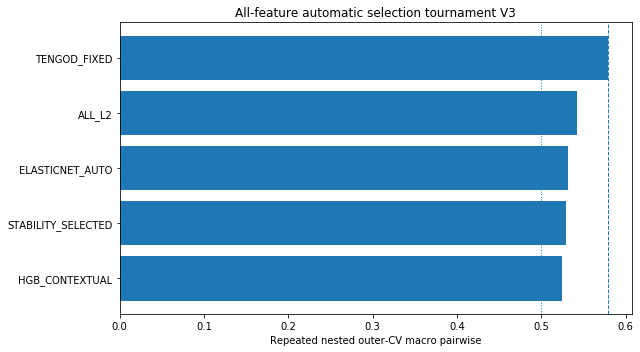

In [23]:
plot_df = leaderboard.sort_values(
    "pairwise_mean",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    plot_df["model"],
    plot_df["pairwise_mean"],
)
ax.axvline(
    0.5,
    linestyle=":",
    linewidth=1,
)
ax.axvline(
    tg_mean,
    linestyle="--",
    linewidth=1,
)
ax.set_xlabel("Repeated nested outer-CV macro pairwise")
ax.set_title("All-feature automatic selection tournament V3")
plt.tight_layout()
plt.show()

# What to send back

After **Restart Kernel → Run All**, send:

```text
research/ml/artifacts/v3_all_feature_tournament/
├── FINAL_nested_leaderboard_v3.csv
├── model_vs_tengod_bootstrap_v3.csv
├── automatic_feature_selection_frequency_v3.csv
├── automatic_family_selection_summary_v3.csv
├── PROVISIONAL_selected_features_v3.csv
├── PROVISIONAL_selected_feature_families_v3.csv
└── PROVISIONAL_ARCHITECTURE_FREEZE_V3.json
```

The three most important files are:

1. `FINAL_nested_leaderboard_v3.csv`
2. `PROVISIONAL_selected_features_v3.csv`
3. `PROVISIONAL_ARCHITECTURE_FREEZE_V3.json`

## Interpretation

If `TENGOD_FIXED` still wins, we can finally say:

> among the current feature universe and tested linear/nonlinear automatic-selection methods,
> the 10-feature Ten-God representation remained the most robust discovery architecture.

If an automatic challenger wins, that selected architecture replaces Ten-God-only **before** building `NEW_DEV_2`.

Either way, `NEW_DEV_2` is the next untouched external replication set.